
Accuracy:
0.9428571428571428

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.92      1.00      0.96        33
           2       0.95      0.90      0.93        21
           3       1.00      0.93      0.97        15

    accuracy                           0.94        70
   macro avg       0.72      0.71      0.71        70
weighted avg       0.93      0.94      0.94        70



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


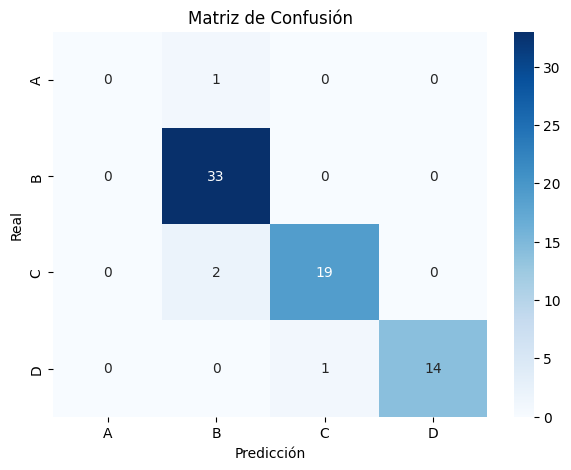

                                             Variable  Importancia
6                Provisiones / Créditos Atrasados (%)     0.146379
10           Créditos Directos / Empleados (Miles S/)     0.133784
3   Créditos Atrasados con más de 90 días de atras...     0.103293
2   Créditos Atrasados (criterio SBS)** / Créditos...     0.091835
8   Gastos de Operación Anualizados / Margen Finan...     0.080618
5   Créditos Atrasados ME (criterio SBS)** / Crédi...     0.062216
12                   Depósitos/ Créditos Directos (%)     0.057274
11  Créditos Directos / Número de Oficinas (Miles S/)     0.053369
7   Gastos de Administración Anualizados/ Créditos...     0.051150
15   Ratio de Liquidez en M.N. (%) (promedio del mes)     0.034290
1   Pasivo Total / Capital Social y Reservas ( Nº ...     0.033682
9   Ingresos Financieros Anualizados / Activo Prod...     0.027718
13  Utilidad Neta Anualizada sobre Patrimonio Prom...     0.027392
4   Créditos Atrasados MN (criterio SBS)** / Crédi...     0.02

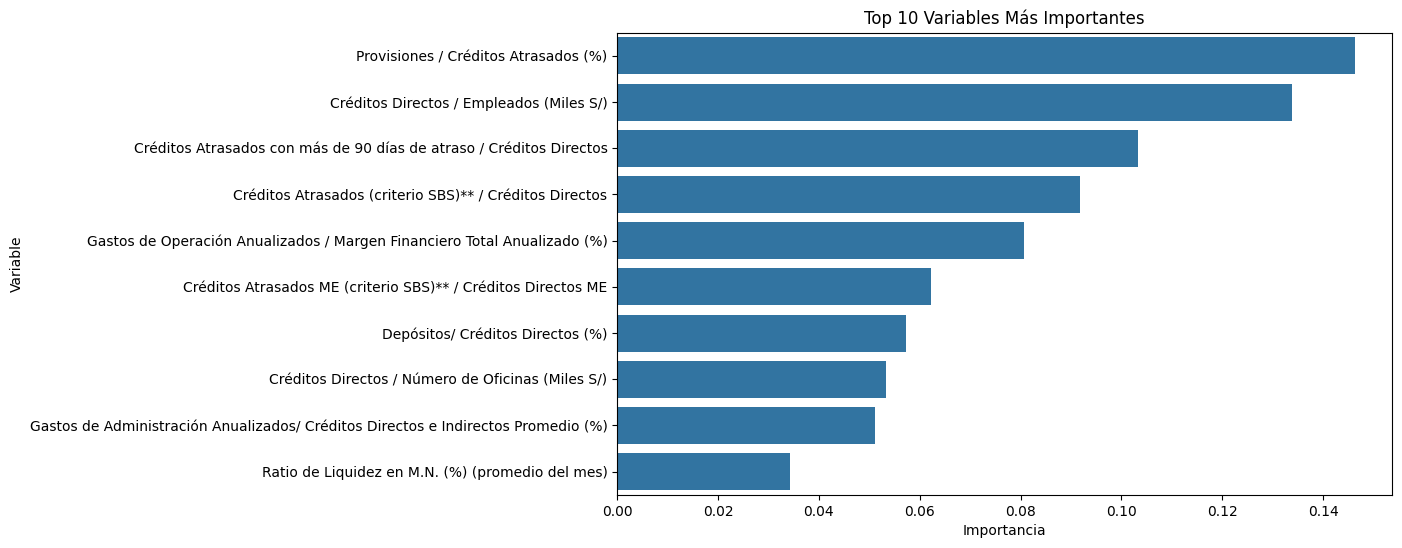

In [1]:
# ==========================================
# MODELO PREDICTIVO DE RIESGO CREDITICIO
# RANDOM FOREST
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# CARGAR EXCEL
# ==========================================

archivo = "bd3.xlsx"

df = pd.read_excel(archivo)

# ==========================================
# TRANSFORMAR MATRIZ
# (filas -> variables, columnas -> casos)
# ==========================================

df = df.set_index("INDICADORES").T

# ==========================================
# VARIABLE OBJETIVO
# ==========================================

y = df["CALIFICACIÓN"]

X = df.drop(columns=["CALIFICACIÓN"])

# convertir a numérico
X = X.apply(pd.to_numeric, errors="coerce")

# ==========================================
# CODIFICAR CLASES
# B=0 C=1 D=2
# ==========================================

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ==========================================
# RANDOM FOREST
# ==========================================

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

modelo.fit(X_train, y_train)

# ==========================================
# PREDICCIONES
# ==========================================

y_pred = modelo.predict(X_test)

# ==========================================
# ACCURACY
# ==========================================

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(acc)

# ==========================================
# REPORTE
# ==========================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# ==========================================
# IMPORTANCIA DE VARIABLES
# ==========================================

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 Variables Más Importantes")
plt.show()